# Phase 3 — Data Preprocessing & EDA

**Mục tiêu:** đọc `food-inspections.csv`, khám phá phân phối, làm sạch, xây dựng entity/target leakage-safe, và xuất artifact graph-ready (Parquet) cho Phase 4.

**Môi trường bắt buộc:** Conda `meibook-dev`.

**Hợp đồng nhãn:**
- Positive: `Fail`
- Negative: `Pass`, `Pass w/ Conditions`
- Horizon: 365 ngày sau anchor inspection
- Same-day policy: chỉ dùng dữ liệu **strictly before** anchor date


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO = Path('..').resolve() if Path.cwd().name == 'notebooks' else Path('.').resolve()
if str(REPO / 'src') not in sys.path:
    sys.path.insert(0, str(REPO / 'src'))

from food_safety_gnn.data_pipeline import PreprocessingConfig, export_graph_ready_data
from food_safety_gnn.provenance import sha256_file
from food_safety_gnn.viz import apply_project_style, bar_chart, line_chart, series_color, CRITICAL, SERIES

apply_project_style()
RAW_CSV = REPO / 'food-inspections.csv'
OUTPUT_DIR = REPO / 'data' / 'interim' / 'phase3' / 'v1'
print('repo:', REPO)
print('raw exists:', RAW_CSV.exists())
print('raw sha256:', sha256_file(RAW_CSV))


repo: /home/jkl/Code/BTL-MH
raw exists: True
raw sha256: 5d243ef9c458f1181b540f4f1b09a8bde8f6a0b044b87c703b0e9afb7d8878d3


## 1. Load raw data & basic profile

In [2]:
raw = pd.read_csv(RAW_CSV, low_memory=False)
raw['Inspection Date'] = pd.to_datetime(raw['Inspection Date'], utc=True).dt.tz_localize(None)

print('shape:', raw.shape)
print('date range:', raw['Inspection Date'].min().date(), '→', raw['Inspection Date'].max().date())
print('columns:', list(raw.columns))
raw.head(3)


shape: (196825, 22)
date range: 2010-01-04 → 2019-12-04
columns: ['Inspection ID', 'DBA Name', 'AKA Name', 'License #', 'Facility Type', 'Risk', 'Address', 'City', 'State', 'Zip', 'Inspection Date', 'Inspection Type', 'Results', 'Violations', 'Latitude', 'Longitude', 'Location', 'Historical Wards 2003-2015', 'Zip Codes', 'Community Areas', 'Census Tracts', 'Wards']


,Inspection ID,DBA Name,AKA Name,License #,Facility Type,Risk,Address,City,State,Zip,...,Results,Violations,Latitude,Longitude,Location,Historical Wards 2003-2015,Zip Codes,Community Areas,Census Tracts,Wards
0,2352683,CHIPOTLE MEXICAN GRILL,CHIPOTLE MEXICAN GRILL,2670642.0,Restaurant,Risk 1 (High),1025 W ADDISON ST,CHICAGO,IL,60613.0,...,Pass w/ Conditions,"3. MANAGEMENT, FOOD EMPLOYEE AND CONDITIONAL E...",41.947118,-87.655381,"{'latitude': '-87.6553811622124', 'longitude':...",NaN,NaN,NaN,NaN,NaN
1,2352734,CHILI'S T-I,CHILI'S (T1-B14),34169.0,Restaurant,Risk 1 (High),11601 W TOUHY AVE,CHICAGO,IL,60666.0,...,Pass,10. ADEQUATE HANDWASHING SINKS PROPERLY SUPPLI...,42.008536,-87.914428,"{'latitude': '-87.91442843927047', 'longitude'...",NaN,NaN,NaN,NaN,NaN
2,2352713,NICK'S FIRE GRILL STEAK & LEMONADE INC.,NICK'S FIRE GRILL STEAK & LEMONADE INC.,2699090.0,NaN,Risk 1 (High),2900 W 63RD ST,CHICAGO,IL,60629.0,...,Not Ready,NaN,41.779190,-87.695892,"{'latitude': '-87.69589237398256', 'longitude'...",NaN,NaN,NaN,NaN,NaN


## 2. EDA — outcome distribution

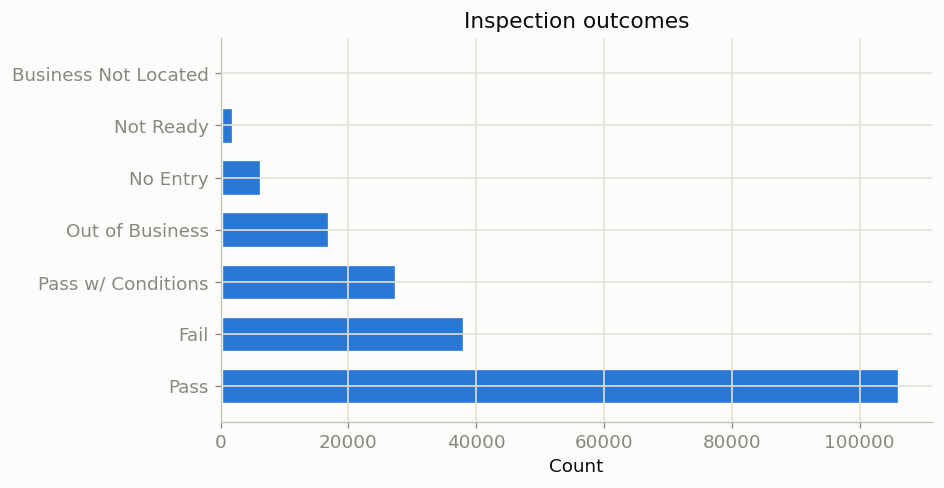

,count
Results,
Pass,106066
Fail,38087
Pass w/ Conditions,27448
Out of Business,16919
No Entry,6324
Not Ready,1912
Business Not Located,69


In [3]:
outcome_counts = raw['Results'].fillna('<missing>').value_counts()
fig, ax = bar_chart(
    outcome_counts.index.tolist(),
    outcome_counts.values.tolist(),
    title='Inspection outcomes',
    ylabel='Count',
    horizontal=True,
    figsize=(8, 4.2),
    color=SERIES[0],
)
plt.show()
outcome_counts.to_frame('count')


## 3. EDA — monthly volume & Fail prevalence

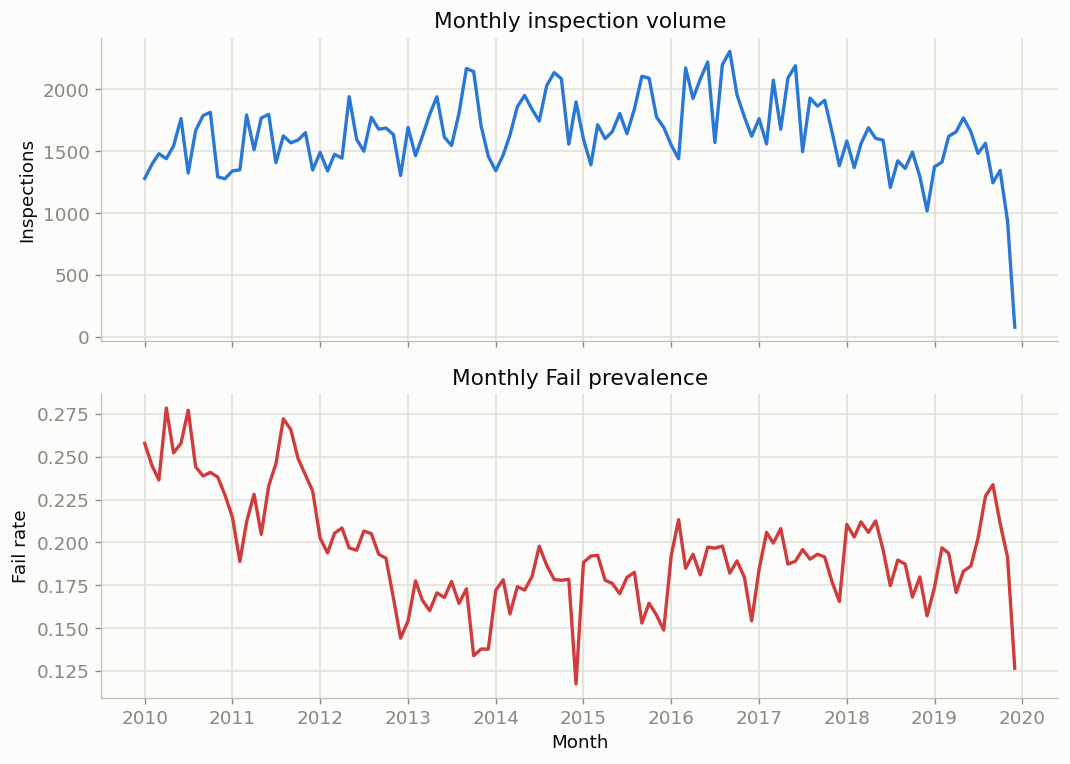

,month,total,fails,fail_rate
115,2019-08-01,1564,355,0.226982
116,2019-09-01,1245,291,0.233735
117,2019-10-01,1345,284,0.211152
118,2019-11-01,935,179,0.191444
119,2019-12-01,79,10,0.126582


In [4]:
monthly = (
    raw.assign(month=raw['Inspection Date'].dt.to_period('M').dt.to_timestamp())
    .groupby('month')
    .agg(total=('Inspection ID', 'size'), fails=('Results', lambda s: (s == 'Fail').sum()))
    .reset_index()
)
monthly['fail_rate'] = monthly['fails'] / monthly['total']

fig, axes = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True)
axes[0].plot(monthly['month'], monthly['total'], color=SERIES[0], linewidth=2)
axes[0].set_title('Monthly inspection volume')
axes[0].set_ylabel('Inspections')
axes[1].plot(monthly['month'], monthly['fail_rate'], color=CRITICAL, linewidth=2)
axes[1].set_title('Monthly Fail prevalence')
axes[1].set_ylabel('Fail rate')
axes[1].set_xlabel('Month')
fig.tight_layout()
plt.show()
monthly.tail()


## 4. EDA — missingness

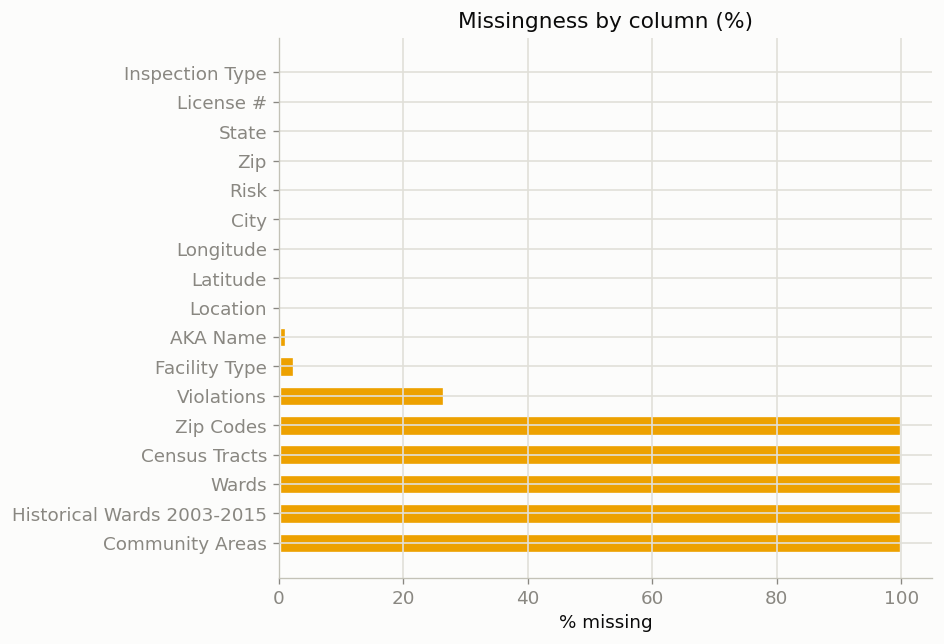

,missing_rate
Community Areas,1.000000
Historical Wards 2003-2015,1.000000
Wards,1.000000
Census Tracts,1.000000
Zip Codes,1.000000
Violations,0.265546
Facility Type,0.024225
AKA Name,0.012488
Location,0.003506
Latitude,0.003506


In [5]:
missing = raw.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
fig, ax = bar_chart(
    missing.index.tolist(),
    (missing.values * 100).tolist(),
    title='Missingness by column (%)',
    ylabel='% missing',
    horizontal=True,
    figsize=(8, 5.5),
    color=SERIES[3],
)
plt.show()
missing.to_frame('missing_rate')


## 5. Clean + export graph-ready Parquet artifacts

In [6]:
config = PreprocessingConfig(
    target_horizon_days=365,
    duplicate_policy='drop_exact_duplicates_only',
    entity_resolution_version='license_address_zip_v1',
    same_day_policy='exclude_same_day_as_not_prior',
)
report = export_graph_ready_data(RAW_CSV, OUTPUT_DIR, config)
print(json.dumps({k: report[k] for k in [
    'input_rows', 'canonical_rows', 'entity_count',
    'eligible_label_count', 'positive_label_count', 'negative_label_count',
    'date_min', 'date_max', 'raw_sha256'
]}, indent=2))
print('outputs:')
for name, path in report['outputs'].items():
    print(f'  - {name}: {path}')


{
  "input_rows": 196825,
  "canonical_rows": 196676,
  "entity_count": 37950,
  "eligible_label_count": 113226,
  "positive_label_count": 20571,
  "negative_label_count": 92655,
  "date_min": "2010-01-04T00:00:00",
  "date_max": "2019-12-04T00:00:00",
  "raw_sha256": "5d243ef9c458f1181b540f4f1b09a8bde8f6a0b044b87c703b0e9afb7d8878d3"
}
outputs:
  - canonical_inspections.parquet: /home/jkl/Code/BTL-MH/data/interim/phase3/v1/canonical_inspections.parquet
  - entity_registry.parquet: /home/jkl/Code/BTL-MH/data/interim/phase3/v1/entity_registry.parquet
  - violation_code_events.parquet: /home/jkl/Code/BTL-MH/data/interim/phase3/v1/violation_code_events.parquet
  - eligible_next_inspection_labels.parquet: /home/jkl/Code/BTL-MH/data/interim/phase3/v1/eligible_next_inspection_labels.parquet


## 6. Inspect eligible next-inspection labels

In [7]:
labels = pd.read_parquet(OUTPUT_DIR / 'eligible_next_inspection_labels.parquet')
print('eligible labels:', len(labels))
print('positive rate:', float(labels['target_label'].mean()))
print('entities labeled:', labels['entity_id'].nunique())
labels[['entity_id', 'Inspection Date', 'Results', 'next_inspection_date', 'next_inspection_result', 'target_label']].head()


eligible labels: 113226
positive rate: 0.18168088601557947
entities labeled: 24069


,entity_id,Inspection Date,Results,next_inspection_date,next_inspection_result,target_label
0,0001501bf8439549cedd,2012-06-15,Fail,2012-06-25,Pass,0
1,0001501bf8439549cedd,2012-06-25,Pass,2013-06-25,Fail,1
2,0001501bf8439549cedd,2013-06-25,Fail,2013-07-12,Fail,1
3,0001501bf8439549cedd,2013-07-12,Fail,2013-07-16,Pass,0
4,0001501bf8439549cedd,2013-07-16,Pass,2014-07-14,Pass w/ Conditions,0


## Artifacts cho Phase 4

| File | Role |
|---|---|
| `canonical_inspections.parquet` | Event-level canonical table + targets |
| `entity_registry.parquet` | Latest convenience lookup (không dùng làm feature lịch sử) |
| `violation_code_events.parquet` | Violation events theo thời gian |
| `eligible_next_inspection_labels.parquet` | Nhãn next-inspection eligible |
| `quality_report.json` | Provenance + quality metrics |
